In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import os

def clean_and_prepare_data():
    print("Loading data...")
    df_posts = pd.read_csv('all_posts_active_subreddit.csv')
    df_com = pd.read_csv('all_comments.csv')

    print("Filtering bots and deleted accounts...")
    bots_and_deleted = ['[deleted]', 'AutoModerator', 'RemindMeBot', 'WikiTextBot', 'image_linker_bot', 'sneakpeekbot']
    
    # Statistics before cleaning
    posts_before = len(df_posts)
    com_before = len(df_com)
    unique_authors_before = set(df_posts['Author'].unique()) | set(df_com['Author'].unique()) - {np.nan}
    
    # Cleaning
    df_posts = df_posts[~df_posts['Author'].isin(bots_and_deleted) & df_posts['Author'].notna()]
    df_com = df_com[~df_com['Author'].isin(bots_and_deleted) & df_com['Author'].notna()]
    
    # Statistics after cleaning
    posts_after = len(df_posts)
    com_after = len(df_com)
    unique_authors_after = set(df_posts['Author'].unique()) | set(df_com['Author'].unique())
    
    deleted_authors = unique_authors_before - unique_authors_after
    
    print(f"--- Data Preparation Summary ---")
    print(f"Unique authors removed: {len(deleted_authors)} ({', '.join(map(str, deleted_authors))})")
    print(f"Posts removed: {posts_before - posts_after}")
    print(f"Comments removed: {com_before - com_after}")
    print(f"Total rows dropped: {(posts_before - posts_after) + (com_before - com_after)}")
    print(f"--------------------------------")

    # Convert dates and get ISO week
    print("Extracting time windows...")
    df_posts['Date & Time'] = pd.to_datetime(df_posts['Date & Time'])
    df_com['Date & Time'] = pd.to_datetime(df_com['Date & Time'])
    
    df_posts['ISOYearWeek'] = df_posts['Date & Time'].dt.strftime('%G-W%V')
    df_com['ISOYearWeek'] = df_com['Date & Time'].dt.strftime('%G-W%V')
    
    print("Building interactions...")
    # Edge type 1: Comment -> Post
    df_com_post = df_com[df_com['Parent ID'].isna()].copy()
    df_com_post = df_com_post.merge(df_posts[['Post ID', 'Author', 'Subreddit']], on='Post ID', how='inner', suffixes=('_com', '_post'))
    df_com_post = df_com_post[df_com_post['Author_com'] != df_com_post['Author_post']]
    
    # Weight: 2 for replying to post, + 0.1 for every 10 chars of content
    df_com_post['Weight'] = 2.0 + (df_com_post['Content'].str.len().fillna(0) / 100.0)
    
    edges_post = df_com_post[['Author_com', 'Author_post', 'Subreddit', 'ISOYearWeek', 'Weight']].rename(
        columns={'Author_com': 'Source', 'Author_post': 'Target'}
    )
    
    # Edge type 2: Comment -> Comment
    df_com_com = df_com[df_com['Parent ID'].notna()].copy()
    df_com_com = df_com_com.merge(df_com[['Comment ID', 'Author']], left_on='Parent ID', right_on='Comment ID', suffixes=('_com', '_parent'))
    df_com_com = df_com_com[df_com_com['Author_com'] != df_com_com['Author_parent']]
    
    # Get Subreddit from Post
    df_com_com = df_com_com.merge(df_posts[['Post ID', 'Subreddit']], on='Post ID', how='inner')
    
    # Weight: 1 for replying to comment, + 0.1 for every 10 chars
    df_com_com['Weight'] = 1.0 + (df_com_com['Content'].str.len().fillna(0) / 100.0)
    
    edges_com = df_com_com[['Author_com', 'Author_parent', 'Subreddit', 'ISOYearWeek', 'Weight']].rename(
        columns={'Author_com': 'Source', 'Author_parent': 'Target'}
    )
    
    # Consolidate all edges
    all_edges = pd.concat([edges_post, edges_com], ignore_index=True)
    
    # Aggregate edge weights for same Source->Target within the same Subreddit and Week
    all_edges = all_edges.groupby(['Source', 'Target', 'Subreddit', 'ISOYearWeek'], as_index=False)['Weight'].sum()
    
    print("Saving consolidated edges...")
    if not os.path.exists('graphs'):
        os.makedirs('graphs')
        
    all_edges.to_csv('graphs/all_edges_consolidated.csv', index=False)
    
    print(all_edges.head())
    print("Pipeline completed.")

if __name__ == '__main__':
    clean_and_prepare_data()


Loading data...
Filtering bots and deleted accounts...
--- Data Preparation Summary ---
Unique authors removed: 5 (RemindMeBot, AutoModerator, [deleted], sneakpeekbot, WikiTextBot)
Posts removed: 2026
Comments removed: 34551
Total rows dropped: 36577
--------------------------------
Extracting time windows...
Building interactions...
Saving consolidated edges...
           Source             Target         Subreddit ISOYearWeek  Weight
0  -----Kyle-----           OhWalter  ClimateOffensive    2020-W03    1.29
1      ---M0NK---  ChemicalLight4133     climatechange    2021-W44    2.99
2      ---M0NK---        Laker4Life9     climatechange    2022-W07    3.92
3      ---M0NK---     LyraSerpentine     climatechange    2022-W07    2.20
4      ---M0NK---        PhilHallUSA     climatechange    2021-W37    2.97
Pipeline completed.


In [2]:
import pandas as pd
import networkx as nx

# Load consolidated edges
edges_df = pd.read_csv('graphs/all_edges_consolidated.csv')

def create_weekly_subreddit_graphs(df):
    graphs = {}
    for (subreddit, year_week), group in df.groupby(['Subreddit', 'ISOYearWeek']):
        if subreddit not in graphs:
            graphs[subreddit] = {}
            
        G = nx.DiGraph()
        for _, row in group.iterrows():
            # Source replied to Target
            G.add_edge(row['Source'], row['Target'], weight=row['Weight'])
            
        graphs[subreddit][year_week] = G
    return graphs

weekly_graphs = create_weekly_subreddit_graphs(edges_df)

def get_top_n_edges(graph, n=10):
    edges = graph.edges(data=True)
    sorted_edges = sorted(edges, key=lambda x: x[2]['weight'], reverse=True)
    return sorted_edges[:n]

# Example top 10 edges for a specific graph (e.g. ClimateActionPlan, first week available)
subreddit_example = 'ClimateActionPlan'
if subreddit_example in weekly_graphs:
    week_example = list(weekly_graphs[subreddit_example].keys())[0]
    example_graph = weekly_graphs[subreddit_example][week_example]
    
    print(f"Top 10 edges for {subreddit_example} in week {week_example}:")
    for edge in get_top_n_edges(example_graph, n=10):
        print(edge)


Top 10 edges for ClimateActionPlan in week 2019-W09:
('dongasaurus_prime', 'WaywardPatriot', {'weight': 103.51})
('dongasaurus_prime', 'MechanicalSpork', {'weight': 74.33})
('WaywardPatriot', 'dongasaurus_prime', {'weight': 23.47})
('dongasaurus_prime', 'ravingllama', {'weight': 22.54})
('DeadlyNadder', 'stevey_frac', {'weight': 17.27})
('MichaelC2585', 'littleendian256', {'weight': 15.87})
('MichaelC2585', 'greg_barton', {'weight': 13.34})
('dongasaurus_prime', 'MichaelC2585', {'weight': 13.26})
('itsallgoodver2', 'PhilCheezSteaks', {'weight': 12.53})
('greg_barton', 'MichaelC2585', {'weight': 12.34})


         2019-W09     2024-W03


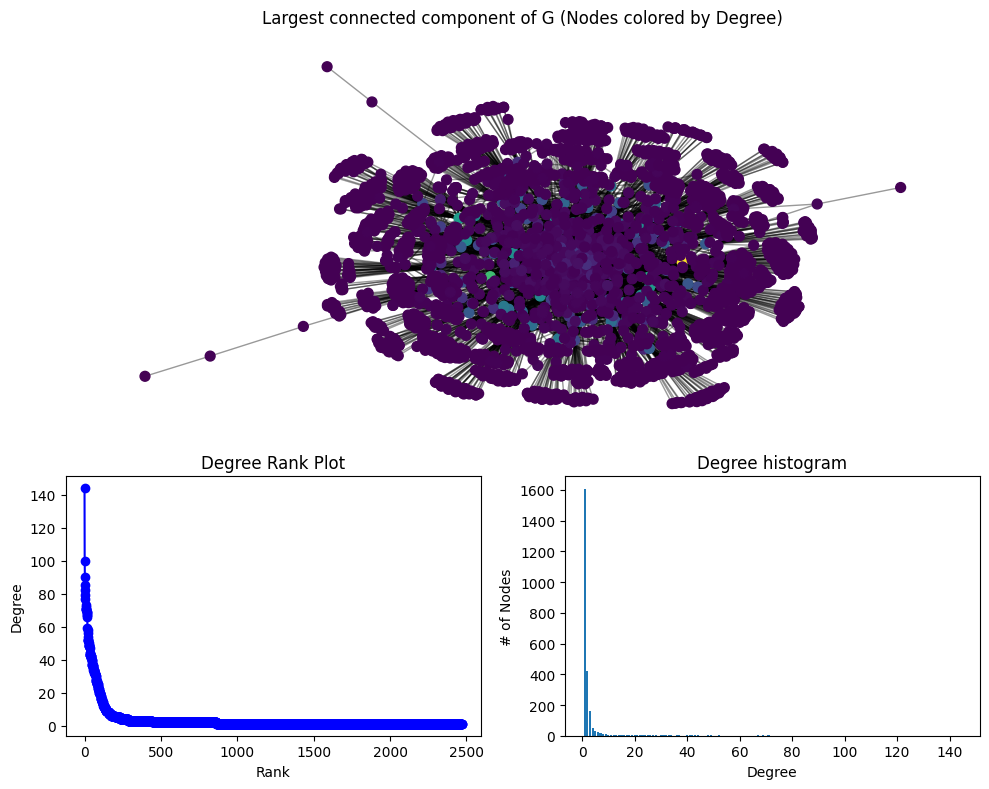

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def plot_graph_between(dic,start_week,endweek):
    print("        ",list(dic.keys())[0] , "   " , list(dic.keys())[-1])
    new_dic={}
    start_year = int(start_week[:4])
    end_year = int(endweek[:4])
    start_week = int(start_week[-2:])
    end_week = int(endweek[-2:])
    time = {"year":start_year, "week":start_week}
    while time["week"]<end_week or time["year"]<end_year:
        str_time = "" + str(time["year"]) 
        str_time += "-W"
        if time["week"]<10:
            str_time += "0" + str(time["week"])
        else:
            str_time += str(time["week"])
        if str_time not in dic:
            break
        new_dic[str_time]=dic[str_time]
        time["week"]+=1
        if time["week"]==53:
            time["week"]=1
            time["year"]+=1
    return nx.Graph(new_dic)


#2021-W05     2023-W50
G=plot_graph_between(weekly_graphs['ClimateActionPlan'],"202102","202403")
degree_sequence = sorted((d for n, d in G.degree()), reverse=True)
dmax = max(degree_sequence)

fig = plt.figure("Degree of a random graph", figsize=(10, 8))
# Create a gridspec for adding subplots of different sizes
axgrid = fig.add_gridspec(5, 4)

ax0 = fig.add_subplot(axgrid[0:3, :])

# Ensure there's a connected component to draw
if G.number_of_nodes() > 0:
    # Get largest connected component
    Gcc = G.subgraph(sorted(nx.connected_components(G), key=len, reverse=True)[0])
    pos = nx.spring_layout(Gcc, seed=10396953)

    # Get node degrees for coloring
    node_degrees = dict(Gcc.degree())
    # Normalize degrees to a range for colormap
    if len(node_degrees) > 0 and max(node_degrees.values()) > 0:
        # Create a colormap based on degree
        cmap = plt.cm.viridis
        # Get colors for nodes based on their normalized degree
        # Smallest degree to 0, largest to 1 for colormap scaling
        min_degree = min(node_degrees.values())
        max_degree = max(node_degrees.values())
        if min_degree == max_degree: # Handle case where all nodes have the same degree
            node_colors = ['blue'] * len(Gcc.nodes())
        else:
            node_colors = [cmap((degree - min_degree) / (max_degree - min_degree)) for degree in node_degrees.values()]

        nx.draw_networkx_nodes(Gcc, pos, ax=ax0, node_size=50, node_color=node_colors)
    else:
        nx.draw_networkx_nodes(Gcc, pos, ax=ax0, node_size=50, node_color='lightblue') # Default if no degrees or single node

    nx.draw_networkx_edges(Gcc, pos, ax=ax0, alpha=0.4)
    #nx.draw_networkx_labels(Gcc, pos, font_size=6, font_family='sans-serif') # Optional: add labels if not too crowded

    ax0.set_title("Largest connected component of G (Nodes colored by Degree)")
else:
    ax0.set_title("No nodes to display in the largest connected component.")

ax0.set_axis_off()

ax1 = fig.add_subplot(axgrid[3:, :2])
if len(degree_sequence) > 0:
    ax1.plot(degree_sequence, "b-", marker="o")
    ax1.set_title("Degree Rank Plot")
    ax1.set_ylabel("Degree")
    ax1.set_xlabel("Rank")
else:
    ax1.set_title("No degrees to plot.")

ax2 = fig.add_subplot(axgrid[3:, 2:])
if len(degree_sequence) > 0:
    ax2.bar(*np.unique(degree_sequence, return_counts=True))
    ax2.set_title("Degree histogram")
    ax2.set_xlabel("Degree")
    ax2.set_ylabel("# of Nodes")
else:
    ax2.set_title("No degrees to plot.")

fig.tight_layout()
plt.show()